In [ ]:
# ============================================================================
# OPTIMIZED FRB SIMULATION: MEERKAT COHERENT BEAM
# ============================================================================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import cumulative_trapezoid # Replaces deprecated cumtrapz
from astropy.cosmology import FlatLambdaCDM


In [ ]:
# ============================================================================
# TELESCOPE SELECTION
# ============================================================================
TELESCOPE = "MeerKAT_coherent"
# Other options: "Fast", "Meerkat_incoherent", "Meerkat_coherent", "askap_ics", "askap_flyeye"

TELESCOPE_PARAMS = {
    "parkes": {
        "D": 64,
        "eta": 0.6,
        "Trec": 28,
        "Tsky": 3,
        "BW": 340e6,
        "nu_cen": 1.382e9,
        "n_comp": 16,
        "n_dishes": 1,
        "n_chan": int(1024*340/400),
        "mode": "multibeam",
        "n_beams": 13,
        "tsamp": 0.064,
        "fov": 0.56,
    },
    "fast": {
        "D": 300,
        "eta": 0.6,
        "Trec": 17,
        "Tsky": 3,
        "BW": 400e6,
        "nu_cen": 1.25e9,
        "n_chan": 2048,
        "n_comp": 8,
        "n_dishes": 1,
        "mode": "multibeam",
        "n_beams": 19,
        "tsamp": 196.608e-6,
        "fov": 0.061,
    },
    "meerkat_incoherent": {
        "D": 13.5,
        "eta": 0.70,
        "Trec": 20,
        "Tsky": 3,
        "BW": 856e6,
        "nu_cen": 1.284e9,
        "n_comp": 16,
        "n_dishes": 64,
        "n_chan": 2048,
        "mode": "incoherent",
        "description": "MeerKAT array - incoherent beam (power addition)",
        "tsamp": 306.24e-6,
        "fov": 1.27,
    },
    "meerkat_coherent": {
        "D": 13.5,
        "eta": 0.70,
        "Trec": 20,
        "Tsky": 3,
        "BW": 856e6,
        "nu_cen": 1.284e9,
        "n_comp": 16,
        "n_dishes": 40,
        "n_chan": 2048,
        "mode": "coherent",
        "description": "MeerKAT array - coherent beam (phase alignment)",
        "tsamp": 306.24e-6,
        "fov": 0.4,
    },
    "askap_ics": {
        "D": 12,
        "eta": 0.6,
        "Trec": 70,
        "Tsky": 3,
        "BW": 336e6,
        "nu_cen": 1.32e9,
        "n_comp": 16,
        "n_dishes": 36,
        "n_chan": 2048,
        "mode": "incoherent",
        "description": "ASKAP array - Incoherent configuration",
        "tsamp": 1.265e-3,
        "fov": 20,
    },
    "askap_flyeye": {
        "D": 12,
        "eta": 0.6,
        "Trec": 70,
        "Tsky": 3,
        "BW": 336e6,
        "nu_cen": 1.32e9,
        "n_comp": 16,
        "n_dishes": 36,
        "n_chan": 2048,
        "mode": "multibeam",
        "description": "ASKAP array - fly's eye configuration",
        "tsamp": 1.265e-3,
        "fov": 160,
    }
}


In [ ]:
alpha_intrinsic = 0  # Fixed intrinsic spectral index

In [ ]:


# Load selected telescope
if TELESCOPE.lower() not in TELESCOPE_PARAMS:
    raise ValueError(f"Telescope must be one of: {list(TELESCOPE_PARAMS.keys())}")

params = TELESCOPE_PARAMS[TELESCOPE.lower()]

# Physical constants
k = 1.38e-23
c = 3.0e8

# Extract telescope parameters
D = params["D"]
eta = params["eta"]
n_dishes = params.get("n_dishes", 1)
mode = params.get("mode", "single")

n_beams = params.get("n_beams", 1) if mode != "coherent" and mode != "incoherent" else 1
array_gain_factor = n_dishes if mode == "coherent" else np.sqrt(n_dishes) if mode == "incoherent" else 1
G0 =  np.pi * D*D/4 * eta/2.0/k*1e-26 * array_gain_factor
nu0 = params["nu_cen"]
Np = 2
Trec = params["Trec"]
Tsky = params["Tsky"]
BW = params["BW"]
n_comp = params["n_comp"]
BW_comp = BW / n_comp
n_chan = params["n_chan"]
BW_chan = BW / n_chan
nu_cen = params["nu_cen"]
nu_min = nu_cen - BW / 2
nu_max = nu_cen + BW / 2
nu_array = np.linspace(nu_min , nu_max , n_comp)

print(f"{'='*100}")
print(f"TELESCOPE: {TELESCOPE}")
print(f"  Diameter: {D} m")
print(f"  Receiver temp: {Trec} K")
print(f"  Bandwidth: {BW/1e6:.0f} MHz at {nu_cen/1e9:.3f} GHz")
print(f"  N_dishes: {n_dishes}, Mode: {mode}")
print(f"  FoV: {params['fov']} deg²")
print(f"{'='*100}\n")


In [ ]:
print(nu_array)

In [ ]:
# 4. Hexagonal Beam Setup
beam_params = pd.read_csv('/home/thsu/FRB_population/MeerKat_beams/beam_parameters.csv')
beam_sep = beam_params['beam_sep'].iloc[0]

R = beam_sep / np.sqrt(3)
beam_positions = np.array([
    [0, R],                    # Top
    [-beam_sep/2, -R/2],       # Bottom-left
    [beam_sep/2, -R/2]         # Bottom-right
])

# Extract arrays once for fast lookup
mk_sigma_x = beam_params['sigma_x'].values
mk_sigma_y = beam_params['sigma_y'].values

def sample_one_frb_in_triangle(beam_positions):
    """Sample one random FRB position within the triangular region."""
    def point_in_triangle(p, v0, v1, v2):
        def sign(p1, p2, p3):
            return (p1[0] - p3[0]) * (p2[1] - p3[1]) - (p2[0] - p3[0]) * (p1[1] - p3[1])
        d1 = sign(p, v0, v1)
        d2 = sign(p, v1, v2)
        d3 = sign(p, v2, v0)
        has_neg = (d1 < 0) or (d2 < 0) or (d3 < 0)
        has_pos = (d1 > 0) or (d2 > 0) or (d3 > 0)
        return not (has_neg and has_pos)
    
    x_min, x_max = beam_positions[:, 0].min(), beam_positions[:, 0].max()
    y_min, y_max = beam_positions[:, 1].min(), beam_positions[:, 1].max()
    
    while True:
        x = np.random.uniform(x_min, x_max)
        y = np.random.uniform(y_min, y_max)
        if point_in_triangle([x, y], beam_positions[0], beam_positions[1], beam_positions[2]):
            return x, y

def get_beam_response_fast(x, y, beam_pos, sig_x_arr, sig_y_arr):
    """Vectorized calculation of beam responses across all frequencies."""
    responses = np.zeros((3, len(sig_x_arr)))
    for i, (bx, by) in enumerate(beam_pos):
        responses[i] = np.exp(-0.5 * (((x - bx)/sig_x_arr)**2 + ((y - by)/sig_y_arr)**2))
    return np.max(responses, axis=0) # Take max across the 3 tying beams

In [ ]:

# ============================================================================
# REDSHIFT PARAMETERS
# ============================================================================
dz = 0.01
z_min = 0.01
z_max = 5.0
z_array_opt = np.arange(z_min, z_max, dz)

# Luminosity function parameters
L_STAR = 1e15  # Characteristic luminosity (Jy·kpc²)
ALPHA_SCH = -1.5  # Faint-end slope
L_MIN_SCH = 1e10
L_MAX_SCH = 1e16

# Simulation parameters
theta_max = 2*1.22*c/D/nu_min # please note here
fscale = 0.2 * 1e-7  # FRB rate scaling factor

SNR_threshold = 10
t_obs = 0.001
TARGET_DETECTIONS = 10  # Target 10 detections per z-bin

# Cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
BL = 800
fwhm_rad = 1.22 * (c / nu_min) / D
fwhm_deg = fwhm_rad * (180 / np.pi)
r_deg = 2.0 * fwhm_deg
area = np.pi * (r_deg)**2
# area = params['fov']  # Area of sky in square degrees

# Calculate frequency-dependent scattering term
freq_powers_scatter = np.array([(nu_min * BW_comp * (i+1))**(-4) for i in range(n_comp)])

np.random.seed(42)

print(f"{'='*100}")
print(f"REDSHIFT PARAMETERS")
print(f"  Redshift range: {z_min:.2f} - {z_max:.2f}")
print(f"  Redshift bin width (dz): {dz}")
print(f"  Number of redshift bins: {len(z_array_opt)}")
print(f"  Sky area: {area} deg²")
print(f"{'='*100}\n")

print(f"LUMINOSITY FUNCTION")
print(f"  Model: Schechter")
print(f"  L* = {L_STAR:.2e} Jy·kpc²")
print(f"  α = {ALPHA_SCH}")
print(f"  L_min = {L_MIN_SCH:.2e}, L_max = {L_MAX_SCH:.2e} Jy·kpc²")
print(f"{'='*100}\n")


In [ ]:
print(area)

In [ ]:
def gaussian_beam_gain(nu, G0, theta, D, c):
    """
    Gaussian beam gain with frequency dependence
    G(ν) = G₀ × exp[−θ²ν²D²×2.355²/(2×1.22²×c²)]
    """
    # Exponent coefficient
    coeff = (theta**2 * D**2 * 2.355**2) / (2 * 1.22**2 * c**2)
    return G0 * np.exp(-coeff * nu**2)

# Pre-calculate constants for speed
_COEFF_CONST = (2.355**2) / (2 * 1.22**2 * (3.0e8**2))

def gaussian_beam_gain_fast(nu_array, G0, theta, D):
    """Optimized version for the inner loop"""
    coeff = theta**2 * D**2 * _COEFF_CONST
    return G0 * np.exp(-coeff * nu_array**2)

def tophat_beam_gain(nu, G0, theta, theta_max):
    """Tophat beam: constant G0 within theta_max/2, zero outside."""
    gain = G0 if theta <= (theta_max / 2) else 0.0
    return np.full_like(nu, gain, dtype=float) if np.ndim(nu) else float(gain)

def SNR(S,t,G,BW,Np,Trec,Tsky):
    return(S*G*np.sqrt(BW*t*Np)/(Trec+Tsky))

In [ ]:
def schechter_function(L, L_star, alpha, phi_star=1.0):
    """
    Schechter luminosity function.
    
    φ(L) = φ* (L/L*)^α * exp(-L/L*)
    
    Parameters:
    -----------
    L : float or array
        Luminosity
    L_star : float
        Characteristic luminosity (knee of the function)
    alpha : float
        Faint-end slope (typically negative)
    phi_star : float
        Normalization constant (default: 1.0)
    
    Returns:
    --------
    phi : float or array
        Number density at luminosity L
    """
    x = L / L_star
    return phi_star * x**alpha * np.exp(-x)

In [ ]:
# ============================================================================
# Lmin for each z bin
# ============================================================================
L_min_by_z = {}
G_max_by_z = {}

for z in z_array_opt:
    # Luminosity distance
    dl = cosmo.luminosity_distance(z).value * 1000  # Mpc to kpc
    
    # Minimum flux at beam center
    G_max = gaussian_beam_gain(nu0, G0, 0, D, 3.0e8)
    S_min = SNR_threshold * (Trec + Tsky) / (G_max * np.sqrt(BW * t_obs * Np))
    
    # Minimum luminosity
    z_factor = (1 + z)**(-1 - alpha_intrinsic)
    L_min = S_min * (dl**2) * z_factor
    
    # Clamp to valid range
    L_min_clamped = np.clip(L_min, L_MIN_SCH, L_MAX_SCH)
    
    L_min_by_z[z] = L_min_clamped
    G_max_by_z[z] = G_max

print(f"  Done! L_min range: {min(L_min_by_z.values()):.3e} - {max(L_min_by_z.values()):.3e}\n")

# =================================================nu===========================
# CREATE TRUNCATED SCHECHTER SAMPLER FOR EACH Z
# ============================================================================
print("Creating truncated Schechter samplers...")

def create_truncated_schechter_sampler(L_min, L_max, L_star, alpha):
    """Create sampler for Schechter function truncated between L_min and L_max"""
    L_grid = np.logspace(np.log10(L_min), np.log10(L_max), 2000)
    phi_grid = schechter_function(L_grid, L_star, alpha)
    
    from scipy.integrate import cumtrapz
    cdf = cumtrapz(phi_grid, L_grid, initial=0)
    cdf = cdf / cdf[-1]
    
    inv_cdf = interp1d(cdf, L_grid, kind='linear', 
                       bounds_error=False, fill_value=(L_min, L_max))
    return inv_cdf

sampler_cache = {}
print(f"  Done!\n")

In [ ]:
# ============================================================================
# MAIN SIMULATION LOOP (INDIVIDUAL SAMPLING VERSION)
# ============================================================================

results_optimized = []
start_time = time.time()

print(f"{'='*100}")
print(f"STARTING SIMULATION: {TELESCOPE}")
print(f"Strategy: Individual sampling with hoisted constants.")
print(f"{'='*100}\n")

# Constant multipliers for the inner loop
S_SNR_CONST = np.sqrt(BW_comp * t_obs * Np) / (Trec + Tsky)
_INNER_COEFF_CONST = (D**2 * 2.355**2) / (2 * 1.22**2 * c**2)
nu0 = nu_cen
nu_scaling = (nu_array / nu0)**alpha_intrinsic 

for z_idx, z in enumerate(z_array_opt):
    zmin = z - 0.5 * dz
    zmax = z + 0.5 * dz
    L_min_z = L_min_by_z[z]
    theta_tiling = np.pi*(0.3119373)/180 # radian

     
    if L_min_z > 8.952e15:
        print(f"\nZ >= {z:.2f}: L_min ({L_min_z:.2e}) > limit. Stopping.")
        break
    
    if L_min_z not in sampler_cache:
        sampler_cache[L_min_z] = create_truncated_schechter_sampler(L_min_z, L_MAX_SCH, L_STAR, ALPHA_SCH)
    truncated_sampler = sampler_cache[L_min_z]
    
    # Pre-compute per-redshift constants
    DM = 1000 * z
    wi_z = 0.001 * (1 + z)
    BW_chan_MHz = BW_chan / 1e6
    nu_cen_GHz = nu_cen / 1e9
    
    w_DM = 8.3e-6 * DM * BW_chan_MHz / (nu_cen_GHz**3)
    w_scatter_comp = 1.9e-7 * (DM**1.5) * (1 + (DM**3) * 3.55e-5) * 3 * freq_powers_scatter * 1e-3
    w_scatter = np.sqrt(np.sum(w_scatter_comp**2) / len(w_scatter_comp))
    w_sampling = params['tsamp'] * 1e-3  # 306.24us for MeerKAT
    
    w_obs_factor = np.sqrt(wi_z**2 + w_DM**2 + w_scatter**2 + w_sampling**2)
    dl = cosmo.luminosity_distance(z).value * 1000
    z_factor = (1 + z)**(-1 - alpha_intrinsic)
    
    n_generated = 0
    n_detected = 0
    detected_luminosities = []
    detected_snrs = []
    max_iterations = 10000000
    
    while n_detected < TARGET_DETECTIONS and n_generated < max_iterations:
        n_generated += 1
        
        # 1. Primary Beam Radial Offset
        theta_frb = theta_max * np.sqrt(np.random.random())

        if theta_frb >= theta_tiling:
            continue  # Skip FRBs outside the tiling radius
        # 2. Coherent Tied Beam internal micro-coordinates
        frb_x, frb_y = sample_one_frb_in_triangle(beam_positions)
        
        lum = float(truncated_sampler(np.random.uniform(0, 1)))
        
        # 3. Apply Multi-Stage Beam Geometry
        beam_responses = get_beam_response_fast(frb_x, frb_y, beam_positions, mk_sigma_x, mk_sigma_y) 
        primary_envelope = np.exp(-(_INNER_COEFF_CONST * theta_frb**2) * nu_array**2)
        
        # 4. Flux Calculation
        S0_frb = (lum / (dl**2 * z_factor)) * (wi_z / w_obs_factor)
        S_nu = S0_frb * nu_scaling
        G_nu = G0 * primary_envelope * beam_responses
        
        # 5. SNR calculation
        snr_spectrum = S_nu * G_nu * S_SNR_CONST
        snr_coherent = np.sum(snr_spectrum) / np.sqrt(len(snr_spectrum)) # sqrt(16)
        
        if snr_coherent > SNR_threshold:
            n_detected += 1
            detected_luminosities.append(lum)
            detected_snrs.append(snr_coherent)

    # Population & Scaling calculations
    if n_detected == TARGET_DETECTIONS:
        detection_rate = n_detected / n_generated
        
        L_grid_full = np.logspace(10, 16, 5000)
        phi_grid_full = schechter_function(L_grid_full, L_STAR, ALPHA_SCH)
        cdf_full = cumulative_trapezoid(phi_grid_full, L_grid_full, initial=0)
        cdf_full /= cdf_full[-1]
        cdf_interp = interp1d(L_grid_full, cdf_full, kind='linear')
        
        N_ratio = 1.0 - cdf_interp(L_min_z)
        psi = 0.015 * ((1+z)**2.7) / (1 + ((1+z)/2.9)**5.6)
        dt = (cosmo.age(zmin).value - cosmo.age(zmax).value) * 1e9
        dvol = (cosmo.comoving_volume(zmax).value - cosmo.comoving_volume(zmin).value) * (area / (4.*np.pi*((180./np.pi)**2)))
        
        nfrb_sfr = psi * dvol * dt * fscale
        n_total_population = detection_rate * N_ratio * nfrb_sfr
        
        results_optimized.append({
            'z': z, 'L_min': L_min_z, 'n_generated': n_generated, 'n_detected': n_detected,
            'detection_rate': detection_rate, 'mean_SNR': np.mean(detected_snrs),
            'mean_detected_L': np.mean(detected_luminosities), 'N_ratio': N_ratio,
            'psi': psi, 'dvol': dvol, 'dt': dt, 'nfrb_sfr_base': nfrb_sfr,
            'n_total_population': n_total_population, 'alpha_intrinsic': alpha_intrinsic
        })
        
        if z_idx % 20 == 0 or z_idx < 5:
            print(f"z={z:.2f}: Generated {n_generated:8d}, Detected {n_detected:2d}, Pop {n_total_population:.1f}")

end_time = time.time()
print(f"\nSIMULATION COMPLETED IN {end_time - start_time:.1f} SECONDS")

In [ ]:
# ============================================================================
# SAVE RESULTS
# ============================================================================
z_results = np.array([r['z'] for r in results_optimized])
alpha_intrinsic_results = np.array([r['alpha_intrinsic'] for r in results_optimized])
L_min_results = np.array([r['L_min'] for r in results_optimized])
n_generated_results = np.array([r['n_generated'] for r in results_optimized])
n_detected_results = np.array([r['n_detected'] for r in results_optimized])
detection_rate_results = np.array([r['detection_rate'] for r in results_optimized])
# ax = axes[1, 2]
mean_snrs = np.array([r['mean_SNR'] for r in results_optimized])
N_ratio_results = np.array([r['N_ratio'] for r in results_optimized])
n_population_results = np.array([r['n_total_population'] for r in results_optimized])

df_summary = pd.DataFrame({
    'z': z_results,
    'alpha_intrinsic': alpha_intrinsic_results,
    'L_min_Jy_kpc2': L_min_results,
    'L_min_over_L_star': L_min_results / L_STAR,
    'n_generated': n_generated_results,
    'n_detected': n_detected_results,
    'detection_rate_10_per_n': detection_rate_results,
    'N_ratio_detectable_L': N_ratio_results,
    'mean_detected_L': np.array([r['mean_detected_L'] for r in results_optimized]),
    'mean_SNR': np.array([r['mean_SNR'] for r in results_optimized]),
    'SFR_psi': np.array([r['psi'] for r in results_optimized]),
    'comoving_volume_Mpc3': np.array([r['dvol'] for r in results_optimized]),
    'time_Gyr': np.array([r['dt'] for r in results_optimized]),
    'nfrb_sfr_base': np.array([r['nfrb_sfr_base'] for r in results_optimized]),
    'n_total_population_scaled': n_population_results
})

csv_file = f"DM_distribution_new/DM_{TELESCOPE.lower()}_alpha{alpha_intrinsic}_scaled.csv"
df_summary.to_csv(csv_file, index=False)
print(f"Results saved to: {csv_file}\n")

print(f"SUMMARY STATISTICS:")
print(f"  Intrinsic spectral index (α): {alpha_intrinsic}")
print(f"  Redshift range: {z_results.min():.2f} - {z_results.max():.2f}")
print(f"  Total z-bins processed: {len(results_optimized)}")
print(f"  Mean n_generated (per 10 detections): {n_generated_results.mean():.1f}")
print(f"  Min/Max n_generated: {n_generated_results.min():.0f} - {n_generated_results.max():.0f}")
print(f"  Average detection_rate (10/n_gen): {detection_rate_results.mean():.6f}")
print(f"  Average N_ratio (detectable fraction): {N_ratio_results.mean():.6f}")
print(f"  Total population (scaled): {n_population_results.sum():.0f}")
print(f"{'='*100}\n")

In [ ]:
# ============================================================================
# VISUALIZATION
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10), dpi=110)

ax = axes[0, 0]
ax.semilogy(z_results, df_summary['L_min_Jy_kpc2'], 'b-o', linewidth=2, markersize=4)
ax.axhline(L_STAR, color='red', linestyle='--', linewidth=2, label='L*')
ax.set_xlabel('Redshift (z)', fontweight='bold')
ax.set_ylabel('L_min (Jy·kpc²)', fontweight='bold')
ax.set_title('Minimum Detectable Luminosity', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(z_results, n_generated_results, 'g-o', linewidth=2, markersize=4)
ax.axhline(TARGET_DETECTIONS, color='red', linestyle='--', linewidth=2, label=f'Target ({TARGET_DETECTIONS})')
ax.set_xlabel('Redshift (z)', fontweight='bold')
ax.set_ylabel('Number Generated', fontweight='bold')
ax.set_title('FRBs Generated to Reach Target', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 2]
ax.semilogy(z_results, detection_rate_results, 'r-o', linewidth=2, markersize=4)
ax.set_xlabel('Redshift (z)', fontweight='bold')
ax.set_ylabel('Efficiency (detections / generated)', fontweight='bold')
ax.set_title('Detection Efficiency vs Redshift', fontweight='bold')
ax.grid(True, alpha=0.3, which='both')

ax = axes[1, 0]
ax.semilogy(z_results, df_summary['N_ratio_detectable_L'], 'b-o', linewidth=2, markersize=4)
ax.set_xlabel('Redshift (z)', fontweight='bold')
ax.set_ylabel('N_ratio (detectable / total)', fontweight='bold')
ax.set_title('Schechter Detection Ratio', fontweight='bold')
ax.grid(True, alpha=0.3, which='both')

ax = axes[1, 1]
ax.plot(z_results, n_population_results, 'purple', marker='o', linewidth=2, markersize=4)
ax.fill_between(z_results, n_population_results, alpha=0.3, color='purple')
ax.set_xlabel('Redshift (z)', fontweight='bold')
ax.set_ylabel('Scaled Population', fontweight='bold')
ax.set_title('Scaled FRB Population per z-bin', fontweight='bold')
ax.grid(True, alpha=0.3)

ax = axes[1, 2]
ax.semilogy(z_results, df_summary['mean_SNR'], 'orange', marker='o', linewidth=2, markersize=4)
ax.axhline(SNR_threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({SNR_threshold})')
ax.set_xlabel('Redshift (z)', fontweight='bold')
ax.set_ylabel('Mean SNR of Detections', fontweight='bold')
ax.set_title('Detection Quality (Mean SNR)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()
print("Visualization complete!")

Wavelength            = 23.35 cm
Primary beam FWHM      = 72.54 arcmin
Coherent beam FWHM     = 73.44 arcsec  (1.224 arcmin)
Tiling diameter        = 37.43 arcmin
Beam spacing (75% FWHM)= 55.08 arcsec
Number of beams (1-D)  = 41


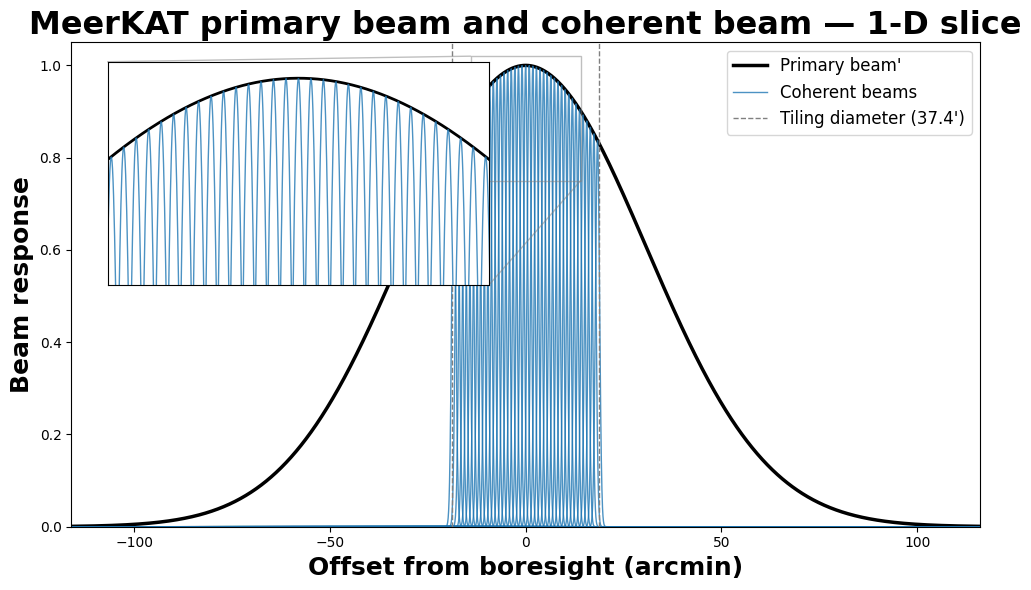

Saved meerkat_beam_1d_slice.png


In [7]:
import numpy as np
import matplotlib
# matplotlib.use("Agg")  # remove/comment this line if running interactively with a display
import matplotlib.pyplot as plt

# ============================================================
# MeerKAT geometry / observing setup  -- EDIT THESE AS NEEDED
# ============================================================
c       = 2.99792458e8     # speed of light, m/s
freq    = 1284e6           # observing frequency, Hz (L-band centre -- change if needed)
wavelength = c / freq      # m

D_dish  = 13.5              # single-dish diameter, m   -> sets the PRIMARY beam
D_max   = 800.0             # max core baseline, m      -> sets the COHERENT (tied-array) beam
overlap = 0.25              # fractional overlap between neighbouring coherent beams

# Tiling diameter, exactly as supplied (radians)
theta_tiling = 2 * np.pi * (0.3119373) / 180   # radians

# ============================================================
# Beam sizes (Gaussian approx. of an Airy pattern: FWHM ~ 1.22 lambda/D)
# ============================================================
fwhm_pb_rad = 1.22 * wavelength / D_dish   # primary beam FWHM, rad
fwhm_cb_rad = 1.22 * wavelength / D_max    # coherent beam FWHM, rad

rad2arcmin = (180.0 / np.pi) * 60.0
fwhm_pb   = fwhm_pb_rad * rad2arcmin       # arcmin
fwhm_cb   = fwhm_cb_rad * rad2arcmin       # arcmin
tiling_diam = theta_tiling * rad2arcmin    # arcmin

# ============================================================
# Beam-centre spacing from the requested fractional overlap.
# "25% overlap" -> each beam centre sits at 75% of a beam-width
# from its neighbour.
# ============================================================
spacing = (1 - overlap) * fwhm_cb          # arcmin
n_side  = int(np.floor((tiling_diam / 2) / spacing))
beam_centres = np.arange(-n_side, n_side + 1) * spacing   # arcmin, symmetric about boresight

print(f"Wavelength            = {wavelength*100:.2f} cm")
print(f"Primary beam FWHM      = {fwhm_pb:.2f} arcmin")
print(f"Coherent beam FWHM     = {fwhm_cb*60:.2f} arcsec  ({fwhm_cb:.3f} arcmin)")
print(f"Tiling diameter        = {tiling_diam:.2f} arcmin")
print(f"Beam spacing (75% FWHM)= {spacing*60:.2f} arcsec")
print(f"Number of beams (1-D)  = {len(beam_centres)}")

# ============================================================
# Gaussian helper
# ============================================================
def gaussian(x, fwhm, x0=0.0, amp=1.0):
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    return amp * np.exp(-0.5 * ((x - x0) / sigma) ** 2)

# ============================================================
# Build the 1-D slice -- full primary beam extent, true to scale
# ============================================================
x_half_range = 1.6 * fwhm_pb                       # arcmin, shows the PB falling to ~0
x = np.linspace(-x_half_range, x_half_range, 6000)  # arcmin
pb = gaussian(x, fwhm_pb)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(x, pb, color='k', lw=2.5,
        label=f"Primary beam'")

for i, x0 in enumerate(beam_centres):
    # the coherent beam's own peak is attenuated by the primary beam
    # response at that pointing offset (a real, physical effect)
    amp = gaussian(x0, fwhm_pb)
    cb = gaussian(x, fwhm_cb, x0=x0, amp=amp)
    lbl = f'Coherent beams ' if i == 0 else None
    ax.plot(x, cb, color='C0', lw=1.0, alpha=0.8, label=lbl)

ax.axvline(-tiling_diam / 2, color='gray', ls='--', lw=1)
ax.axvline(tiling_diam / 2, color='gray', ls='--', lw=1,
           label=f"Tiling diameter ({tiling_diam:.1f}')")
# ax.axhline(0.5, color='gray', ls=':', lw=0.8)

ax.set_xlabel('Offset from boresight (arcmin)', fontsize=18, fontweight='bold')
ax.set_ylabel('Beam response', fontsize=18, fontweight='bold')
ax.set_title('MeerKAT primary beam and coherent beam — 1-D slice', fontsize=23, fontweight='bold')
ax.legend(loc='upper right', fontsize=12)
ax.set_xlim(-x_half_range, x_half_range)
ax.set_ylim(0, 1.05)

# ------------------------------------------------------------
# Zoomed inset showing the coherent-beam tiling detail, since at
# full primary-beam scale the small beams are too thin to resolve.
# ------------------------------------------------------------
zoom_half = 0.75 * tiling_diam / 2   # arcmin, inset window
axins = ax.inset_axes([0.04, 0.50, 0.42, 0.46])  # [x0, y0, width, height] in axes coords

axins.plot(x, pb, color='k', lw=2.0)
for i, x0 in enumerate(beam_centres):
    amp = gaussian(x0, fwhm_pb)
    cb = gaussian(x, fwhm_cb, x0=x0, amp=amp)
    axins.plot(x, cb, color='C0', lw=1.0, alpha=0.8)
axins.axvline(-tiling_diam / 2, color='gray', ls='--', lw=1)
axins.axvline(tiling_diam / 2, color='gray', ls='--', lw=1)
axins.set_xlim(-zoom_half, zoom_half)
axins.set_ylim(0.75, 1.02)
axins.set_xticks([])
axins.set_yticks([])
# axins.set_title('zoom: coherent beam tiling', fontsize=9)

ax.indicate_inset_zoom(axins, edgecolor='gray')

fig.tight_layout()
plt.show()
# fig.savefig('meerkat_beam_1d_slice.png', dpi=150)
print("Saved meerkat_beam_1d_slice.png")